<div style="display: flex; align-items: center; width: 100%;">
  <div style="display: flex; flex-direction: column; align-items: center; justify-content: center; width: 100px; margin-right: 0px;">
    <a href="https://risklab.ai" style="border: 0; line-height: 0.5;">
      <img src="../Utils/risklab_ai.gif" width="60px" style="border: 0; margin-bottom:-10px; vertical-align: middle;"/>
    </a>
  </div>
  <div style="flex-grow: 1;">
    <h1 style="margin: 0; margin-left:0; font-weight: bold; text-align: left; font-size: 38px;">
      Overfitting: path-level Bagged and Adaptive CPCV
    </h1>
  </div>
</div>

De Prado's **CPCV / CSCV** estimates the Probability of Backtest Overfitting
(PBO) from a finite set of combinatorial performance paths and weights every path
equally. Two path-level upgrades (Arian-Norouzi-Seco 2024): **Bagged CPCV**
bootstrap-aggregates the paths to cut the PBO estimate's variance; **Adaptive
CPCV** weights paths by how much their test block resembles the forward regime
(from an observable volatility signal), lowering selection error under regime
shifts.

*Baseline (plain CPCV) -> where it breaks (noisy estimate / regime shift) -> Bagged / Adaptive.*

In [1]:
using Pkg
Pkg.activate(joinpath(@__DIR__, ".."))   # the pinned notebook environment

using Random, Statistics, Plots
gr()
theme(:default)                            # theme-adaptive figures (legible on light & dark)
default(background_color = :transparent, background_color_inside = :transparent,
        foreground_color = "#888888", gridalpha = 0.3,
        legend_background_color = :transparent)
using RiskLabAI.Backtest: probability_of_backtest_overfitting
using RiskLabAI.Validation: bagged_probability_of_backtest_overfitting,
    adaptive_probability_of_backtest_overfitting, estimate_volatility_regimes

  Activating project at `C:\risklab\risklabai\Notebooks.jl`


## 1. Plain vs Bagged PBO on a noisy performance matrix
`T` periods x `N` candidate strategies of mostly-noise returns; bagging the paths
gives a lower-variance PBO estimate.

plain CPCV PBO   = 0.086
bagged CPCV PBO  = 0.097   (mean of 40 resamples, std 0.118)


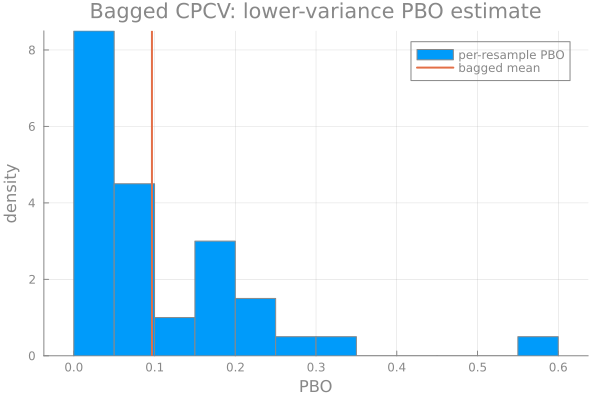

In [2]:
rng = MersenneTwister(0)
T, N = 240, 10
perf = 0.02 .* randn(rng, T, N)
perf[:, 1] .+= 0.004          # one mildly better strategy
plain, _ = probability_of_backtest_overfitting(perf; n_partitions = 8)
bagged, per_resample = bagged_probability_of_backtest_overfitting(
    perf; n_partitions = 8, n_bag = 40, rng = MersenneTwister(1))
println("plain CPCV PBO   = ", round(plain, digits = 3))
println("bagged CPCV PBO  = ", round(bagged, digits = 3),
        "   (mean of ", length(per_resample), " resamples, std ",
        round(std(per_resample), digits = 3), ")")
histogram(per_resample; bins = 15, label = "per-resample PBO", normalize = true,
          xlabel = "PBO", ylabel = "density", title = "Bagged CPCV: lower-variance PBO estimate")
vline!([bagged]; label = "bagged mean", lw = 2)

## 2. Adaptive CPCV under a regime shift
The forward block is a different volatility regime; adaptive weighting steers
selection toward the regime that matters at decision time.

In [3]:
rng = MersenneTwister(2)
perf2 = 0.02 .* randn(rng, T, N)
perf2[1:170, 2] .+= 0.006             # strategy 2 leads early
perf2[171:T, :] .*= 3.0               # forward block is high-volatility
perf2[171:T, 9] .+= 0.02              # strategy 9 leads in the forward regime
regimes = estimate_volatility_regimes(perf2; n_regimes = 2)
pbo_ad, selected = adaptive_probability_of_backtest_overfitting(perf2; n_partitions = 8)
println("estimated regimes (last 10): ", regimes[end-9:end])
println("adaptive PBO = ", round(pbo_ad, digits = 3),
        "   regime-aware selected strategy = ", selected)

estimated regimes (last 10): [1, 1, 1, 1, 1, 1, 1, 1, 1, 1]
adaptive PBO = 0.044   regime-aware selected strategy = 9


## When to use / when NOT (from `appraisals/09_verdict.md`)
**Prefer Bagged CPCV over plain CPCV for a more accurate, lower-variance PBO
estimate whenever the CPCV path set is small or noisy** (converges to plain CPCV
in the data-rich limit; neutral on model selection). **Prefer Adaptive CPCV for
model selection when the train/test regime may shift, the shift is identifiable at
decision time from observable volatility, and there is adequate data** (it does not
help where selection is noise-dominated by too little data; converges to plain CPCV
in a stationary regime).